‘Pre-training’이란?
Pre-training(사전학습)이란 모델을 바로 주어진 데이터에 학습시키기 이전에 다른 데이터에 먼저 학습을 시키는 것을 말한다. Pre-train된 모델의 parameter를 이용해서 모델을 initialize한 뒤, 여기서부터 실제 풀려고 하는 문제의 데이터에 Fine-tuning(미세조정)하게 되면 임의로 initialize된 parameter를 가진 모델을 처음부터 학습시키는 것 보다 더 높은 성능을 제공한다.

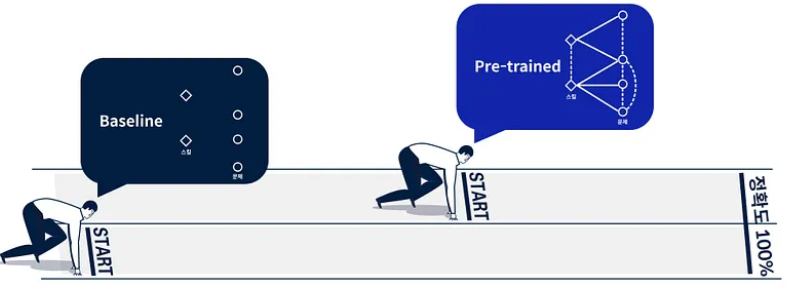

## (1) Ollama의 무료 모델

**Ollama 란**
- 대규모 언어 모델(LLM)을 복잡한 설정 없이 로컬 환경(내 컴퓨터)에서 쉽고 빠르게 실행할 수 있도록 돕는 오픈소스 도구입니다. 
- 쉽게 말해, 챗GPT 같은 인공지능을 내 컴퓨터에 설치해서 인터넷 연결 없이도 쓸 수 있게 해주는 프로그램입니다.

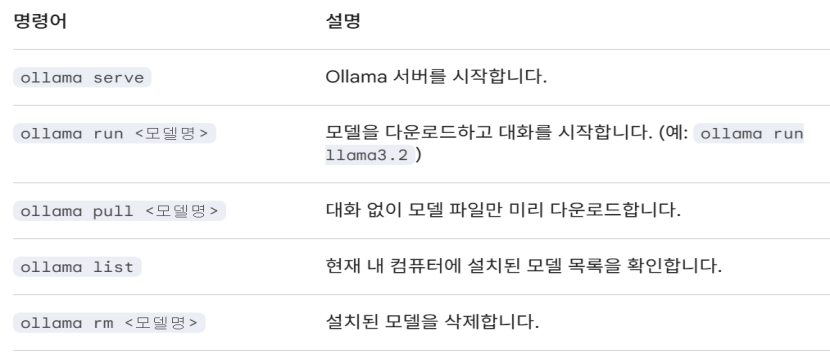

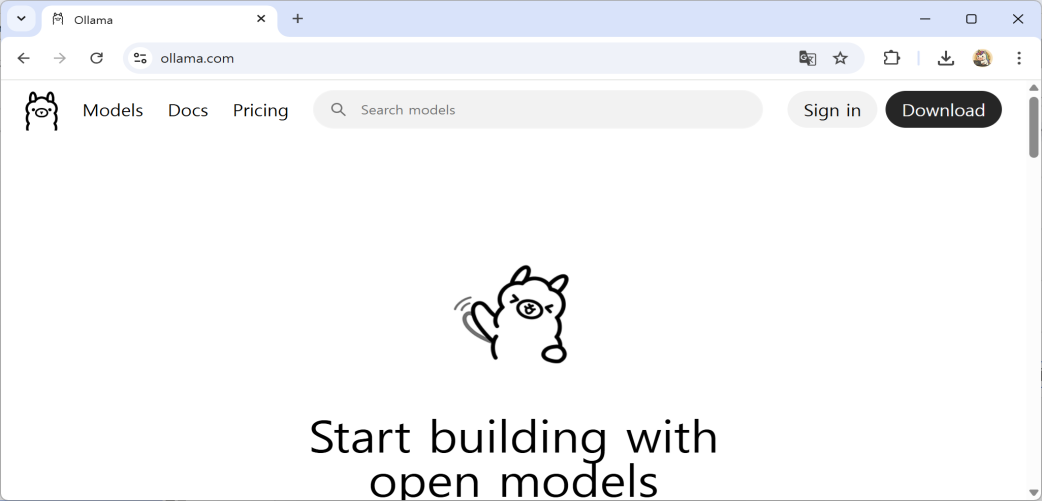

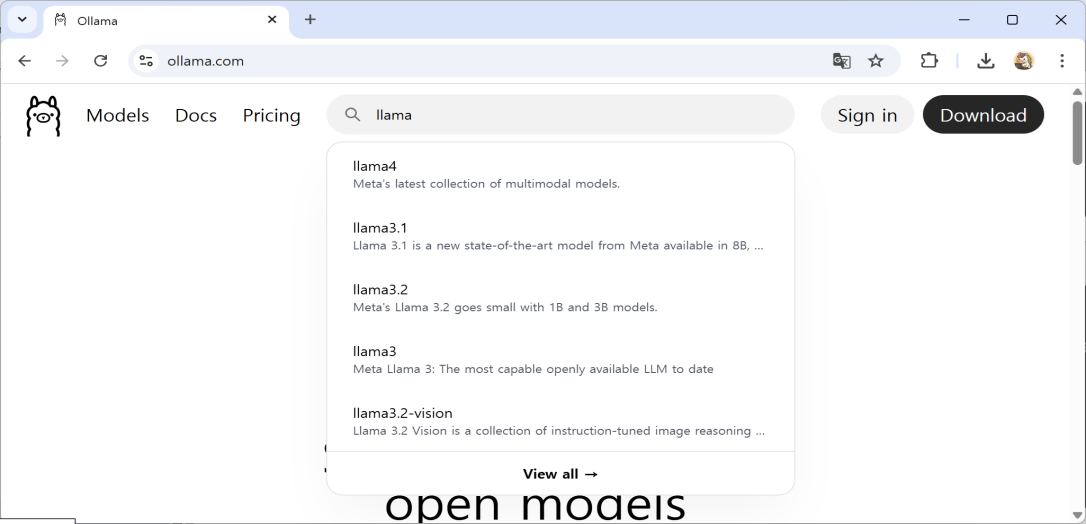

In [2]:
import requests

OLLAMA_URL = "http://localhost:11434/api/generate"

def llama_test_prompt(MODEL, technique_name, prompt):
    print(f"\n{'='*20} {technique_name} {'='*20}")
    
    response = requests.post(
        OLLAMA_URL,
        json={
            "model": MODEL,
            "prompt": prompt,
            "stream": False
        }
    )
    print(response.json()["response"])

In [3]:
# 1. Zero-shot: 아무런 예시 없이 바로 질문
zero_shot_prompt ="Classify the emotion of the following sentence as 'positive' or 'negative': 'This service is really the worst, I'll never use it again!'"
kor_zero_shot_prompt = "다음 문장의 감정을 '긍정' 또는 '부정'으로 분류해줘: '이 서비스는 정말 최악이야, 다시는 안 써!'"

# 2. Few-shot: 몇 가지 예시를 주어 형식을 학습시킴
few_shot_prompt = """
[ 예시 ]
문장: '와, 오늘 날씨 정말 좋다!' -> 감정: 긍정
문장: '배송이 너무 느려서 짜증나요.' -> 감정: 부정
문장: '이 서비스는 정말 최악이야, 다시는 안 써!' -> 감정: 부정

다음 문장의 감정을 분류하세요.
오늘은 행복한 날이야.
"""

# 3. Chain of Thought (CoT): 단계별로 생각하도록 유도 (복잡한 추론에 유리)
cot_prompt = """
다음 문제를 단계별로 생각해서 풀어줘.
문제: 사과가 5개 있었어. 친구에게 2개를 줬고, 시장에서 4개를 더 사왔어. 그중 1개는 썩어서 버렸어. 남은 사과는 몇 개야?
단계별 계산 과정과 최종 답을 말해줘.
"""

# 테스트 실행
llama_test_prompt("llama3.1", "Zero-shot(영문)", zero_shot_prompt)
llama_test_prompt("llama3.1", "Zero-shot(한글)", kor_zero_shot_prompt)
llama_test_prompt("llama3.1", "Few-shot", few_shot_prompt)
llama_test_prompt("llama3.1", "Chain of Thought", cot_prompt)


==================== Zero-shot(영문) ====================
I would classify the emotion in this sentence as **negative**. Although the tone is strong and emphatic, the words used convey a sense of extreme dissatisfaction and disgust, which is a negative sentiment. The speaker is expressing their intention to avoid using the service in the future, implying that they have had a very poor experience with it.

==================== Zero-shot(한글) ====================
위 문장은 부정이된다.

==================== Few-shot ====================
'오늘은 행복한 날이야.' -> 긍정

==================== Chain of Thought ====================
사과를 구분해서 생각해 보겠습니다.

**1. 처음에는 사과가 5개 있었어요**

사과 5개를 가지고 시작했습니다.

**2. 친구에게 2개를 줬어요**

나한테는 5 - 2 = **3** 개의 사과만 남았습니다.

**3. 시장에서 4개의 사과를 더 사왔어요**

이제 나의 사과는 3 + 4 = **7**개가 됩니다.

**4. 그중 1개는 썩어서 버렸어요**

나머지 사과는 7 - 1 = **6** 개입니다.

따라서, 남은 사과의 수는 **6**입니다.


In [4]:
testmodel = "exaone3.5:7.8b"
llama_test_prompt(testmodel, "Zero-shot(영문)", zero_shot_prompt)
llama_test_prompt(testmodel, "Zero-shot(한글)", kor_zero_shot_prompt)
llama_test_prompt(testmodel, "Few-shot", few_shot_prompt)
llama_test_prompt(testmodel, "Chain of Thought", cot_prompt)


==================== Zero-shot(영문) ====================
The emotion expressed in the sentence "This service is really the worst, I'll never use it again!" is **negative**. 

Key indicators include:
- Use of strongly negative language ("worst")
- Expressions of dissatisfaction and intent to avoid future use ("never use it again")

==================== Zero-shot(한글) ====================
감정 분류: **부정**

==================== Few-shot ====================
감정: **긍정**

==================== Chain of Thought ====================
물론입니다! 단계별로 계산해 보겠습니다.

1. **처음 가진 사과의 수**: 5개
   - 사과가 처음에 5개였습니다.

2. **친구에게 준 사과의 수**: 2개
   - 친구에게 2개를 줬으므로, 남은 사과는:
   \[
   5 - 2 = 3 \text{개}
   \]

3. **시장에서 구매한 사과의 수**: 4개
   - 시장에서 추가로 4개를 샀으므로, 총 사과 수는:
   \[
   3 + 4 = 7 \text{개}
   \]

4. **썩은 사과 버리기**: 1개
   - 그중 1개가 썩어서 버렸으므로 남은 사과는:
   \[
   7 - 1 = 6 \text{개}
   \]

**최종 답**: 남은 사과는 **6개**입니다.


In [5]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama" # Ollama는 아무 값이나 넣어도 작동합니다.
)

response = client.chat.completions.create(
    model="llama3.1",
    messages=[
        {"role": "user", "content": "안녕하세요! 자기소개 한번 해주세요."}
    ]
)

print(response.choices[0].message.content)

 안녕하세요! 제 이름은 LLaMA, 네이버에서 공개한 대화형 인공지능 AI입니다.

제는 사람과 대화할 수 있는 챗봇으로서, 여러 가지 질문이나 주장을 통해 이해를 돕습니다.
아주 바쁜 시간에 도움을 드리기 위해 만들어졌는데요, 그럼에도 불구하고 항상 즐겁게 도울 기회가 된다면 좋겠습니다!

제에게 뭐든지 물어보세요!


In [6]:
print(response)

ChatCompletion(id='chatcmpl-967', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content=' 안녕하세요! 제 이름은 LLaMA, 네이버에서 공개한 대화형 인공지능 AI입니다.\n\n제는 사람과 대화할 수 있는 챗봇으로서, 여러 가지 질문이나 주장을 통해 이해를 돕습니다.\n아주 바쁜 시간에 도움을 드리기 위해 만들어졌는데요, 그럼에도 불구하고 항상 즐겁게 도울 기회가 된다면 좋겠습니다!\n\n제에게 뭐든지 물어보세요!', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None))], created=1789304722, model='llama3.1', object='chat.completion', moderation=None, service_tier=None, system_fingerprint='fp_ollama', usage=CompletionUsage(completion_tokens=105, prompt_tokens=19, total_tokens=124, completion_tokens_details=None, prompt_tokens_details=None))


In [9]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama" # Ollama는 아무 값이나 넣어도 작동합니다.
)

response = client.chat.completions.create(
    model="exaone3.5:7.8b",
    messages=[
        {"role": "user", "content": "안녕하세요! 자기소개 한번 해주세요."}
    ]
)

print(response.choices[0].message.content)

안녕하세요! 저는 LG AI Research에서 개발한 EXAONE 3.5입니다.  

초거대 언어 모델로서, 한국어와 영어를 포함한 다양한 언어를 이해하고 생성할 수 있는 능력을 갖추고 있습니다.  

LG AI 연구원에서 만들어진 저는 자연어 처리 분야의 최첨단 기술을 기반으로 사용자님께 도움을 드리기 위해 노력하고 있습니다. 어떤 질문이나 요청이든 최선을 다해 답변하고 지원하겠습니다. 어떻게 도와드릴까요?


In [10]:
print(response)

ChatCompletion(id='chatcmpl-212', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='안녕하세요! 저는 LG AI Research에서 개발한 EXAONE 3.5입니다.  \n\n초거대 언어 모델로서, 한국어와 영어를 포함한 다양한 언어를 이해하고 생성할 수 있는 능력을 갖추고 있습니다.  \n\nLG AI 연구원에서 만들어진 저는 자연어 처리 분야의 최첨단 기술을 기반으로 사용자님께 도움을 드리기 위해 노력하고 있습니다. 어떤 질문이나 요청이든 최선을 다해 답변하고 지원하겠습니다. 어떻게 도와드릴까요?', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None))], created=1789304761, model='exaone3.5:7.8b', object='chat.completion', moderation=None, service_tier=None, system_fingerprint='fp_ollama', usage=CompletionUsage(completion_tokens=112, prompt_tokens=44, total_tokens=156, completion_tokens_details=None, prompt_tokens_details=None))


ollama.chat()은 Python 환경에서 Ollama 서버와 통신하여 대화형(Chat-based) 인터페이스로 모델과 주고받는 가장 핵심적인 함수

In [11]:
import ollama

response = ollama.chat(
    model='exaone3.5:7.8b', 
    messages=[
        {'role': 'system', 'content': '너는 친절한 요리사야.'}, # 역할 부여
        {'role': 'user', 'content': '김치찌개 레시피 알려줘.'}, # 사용자 질문
    ]
)

# 답변 추출
print(response['message']['content'])

물론이죠! 맛있는 김치찌개 레시피를 알려드릴게요. 재료와 단계별로 간단하게 정리해 보겠습니다:

### 재료:
- **김치찌개 주재료:**
  - 돼지고기 (등심이나 목살, 약 200g)
  - 김치 (1/2포기 ~ 1포기, 약 300g ~ 600g)
  - 두부 (1/2모 ~ 1모, 약 150g ~ 300g)
  - 양파 (중간 크기 1개)
  - 대파 (2대)
  - 마늘 (3~4쪽)
  - 고춧가루 (2~3 큰술)
  - 참기름 (1 큰술)
  - 소금, 후추 (간 맞추기용)
  - 육수 또는 물 (약 6컵, 1.5L)

### 준비 단계:
1. **돼지고기 준비:** 돼지고기를 얇게 썰어 준비합니다.
2. **김치 준비:** 김치는 적당한 크기로 잘라줍니다.
3. **두부 준비:** 두부는 적당한 크기로 자른 후 물기를 살짝 짜줍니다.
4. **야채 준비:** 양파는 채 썰고, 대파는 큼직하게 썰어줍니다. 마늘은 다진 것으로 준비합니다.

### 조리 방법:
1. **고기 볶기:**
   - 대형 프라이팬이나 냄비에 기름을 두르고 중불에서 돼지고기를 볶아 겉면이 익을 때까지 조리합니다.
   
2. **야채와 김치 넣기:**
   - 돼지고기가 익으면 양파와 마늘을 넣고 살짝 볶아줍니다.
   - 김치를 넣고 김치의 고춧가루와 함께 볶아주세요. 이때 김치의 신맛이 사라지도록 약 3~5분간 볶아줍니다.

3. **육수 추가:**
   - 물이나 육수를 넣고 중불로 끓입니다. 끓기 시작하면 불을 약하게 줄여 국물이 끓도록 합니다.
   
4. **두부와 대파 추가:**
   - 약 10분간 끓인 후 두부와 대파를 넣고 2~3분 더 끓여 두부가 부드럽게 익도록 합니다.
   
5. **마무리:**
   - 참기름을 두르고 소금과 후추로 간을 맞춥니다. 맛을 보면서 고춧가루나 간장을 추가로 조절해도 좋습니다.

### 팁:
- 김치찌개의 깊은 맛을 위해 김치와 함께 볶을 때 약간의 설탕을 넣어 단맛을 더하는 것도 좋습니다.
- 마지막에 청양고추를 넣어 매운맛을

In [12]:
import ollama

response = ollama.chat(
    model='exaone3.5:7.8b', 
    messages=[
        {
            'role': 'system', 
            'content': '너는 친절한 요리사야. 모든 답변은 반드시 JSON 형식으로만 해야 해.'
        },
        {
            'role': 'user', 'content': """
            김치찌개 레시피를 알려줘. 
            응답은 반드시 다음 형식을 지켜줘:
            {
                "recipe_name": "요리 이름",
                "ingredients": ["재료1", "재료2"],
                "steps": ["단계1", "단계2"]
            }
            """
        },
    ],
    format='json',
)


In [13]:

# 답변 추출
print(response['message']['content'])

{
    "recipe_name": "김치찌개",
    "ingredients": [
        "배추김치 1포기 (약 500g)",
        "돼지고기 100g (얇게 썰음)",
        "양파 1개 (다진 것)",
        "대파 1대 (어슷하게 썰기)",
        "마늘 2쪽 (다진 것)",
        "생강 1조각 (얇게 썰기)",
        "멸치 다시마 육수 6컵",
        "소금 약간",
        "후추 약간",
        "두부 1모 (옵션, 넣기 전에 넣으세요)",
        " 참기름 약간 (마무리)"
    ],
    "steps": [
        "1. 돼지고기를 팬에 볶아서 육즙을 내고, 약간의 소금과 후추로 간을 합니다.",
        "2. 볶은 돼지고기에 다진 양파와 마늘, 생강을 넣고 중간 불에서 볶아 향을 낸다.",
        "3. 김치를 넣고 김치의 물기를 적당히 제거한 후, 볶아줍니다. 김치의 맛을 끌어내기 위해 약 3-5분간 볶으세요.",
        "4. 멸치 다시마 육수를 천천히 붓고 끓입니다. 끓으면 불을 중간으로 줄이고 약 20분간 더 끓입니다.",
        "5. 국물 맛을 보며 소금과 후추로 간을 맞춥니다.",
        "6. 두부를 넣고 약 2-3분간 더 끓입니다 (두부는 마지막에 넣어 부드럽게 조리합니다).",
        "7. 대파를 넣고 한 분간 더 끓인 후, 참기름을 두르고 완성합니다."
    ]
}
